# Forecasting Analysis

Modified from *Using Deep Learning for Flexible and Scalable Earthquake Forecasting*.
Reference: [Zenodo](https://zenodo.org/records/8161777)

## 1) Setup

In [1]:
import os
import sys
import functools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src
import src.utils.catalog_tests as catalog_tests
from src.train.config_setup import load_and_prepare_model
from src.utils.tpp_experiments import load_tpp_catalog, sample_tpp_forecasts
from src.utils.utils import set_seed
from src.utils.viz_sequences import visualize_sequence

set_seed(0)
np.random.seed(0)
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/em_eqf
DEVICE: cuda:0


## 2) Configuration

In [3]:
CHECKPOINT_DIR = PROJECT_ROOT/'checkpoints/etas_20260507-164840'  # 'checkpoints/mixer_tpp_20260205-110204'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'

USE_TORCH_COMPILE = False
# MODEL_MM = 6.0  # set to None to skip overriding model.M_m
MODEL_MM = None

print(f'CHECKPOINT_PATH: {CHECKPOINT_PATH}')

CHECKPOINT_PATH: /root/autodl-tmp/em_eqf/checkpoints/etas_20260507-164840/best_model_1.pth


## 3) Load Trained Model

In [4]:
model, args = load_and_prepare_model(
    checkpoint_path=CHECKPOINT_PATH,
    device=DEVICE,
    compile=USE_TORCH_COMPILE,
)

if MODEL_MM is not None and hasattr(model, 'M_m'):
    model.M_m = torch.tensor(float(MODEL_MM), device=DEVICE)

print(f'Model: {args.model} | Dataset: {args.dataset}')

Model: etas | Dataset: ChuanDian


In [5]:
model.M_m

tensor(10, device='cuda:0')

In [7]:
model.print_params()
model.effective_branching_ratio(t_max=1000)
# model.base_model.input_adapter.richter_b
# model.base_model.input_adapter.mag_completeness

ETAS model parameters:
  p = 1.0816421508789062
  c = 0.024366363883018494
  mu = 0.25504782795906067
  k = 0.017839400097727776
  K = 0.29591819643974304
  alpha = 0.6107501983642578
  alpha_e = 1.4063043594360352
  b = 0.7449380159378052
  M_c = 3.0
  M_m = 10.0


0.8430807221380888

## 4) Load Catalog and Visualize

In [8]:
# args.catalog_cfg['mag_completeness']=4.7

Using catalog registry name: ChuanDian-Standard


<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

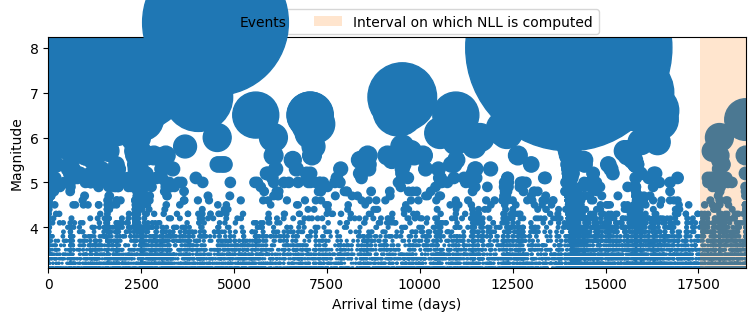

In [9]:
catalog_ds, registry_name, catalog_init_kwargs = load_tpp_catalog(
    args.dataset,
    base_dir=PROJECT_ROOT / 'data' / args.dataset,
    catalog_cfg=getattr(args, 'catalog_cfg', {}),
)
print(f'Using catalog registry name: {registry_name}')

train_seq = catalog_ds.train[0]
test_seq = catalog_ds.test[0]

visualize_sequence(test_seq, show_nll=True)

In [10]:
catalog_ds.full_sequence

Sequence(
  inter_times: [11581],
  arrival_times: [11580],
  t_start: 0.0,
  t_end: 18771.0,
  t_nll_start: 0.0,
  mag: [11580],
  loc: [11580, 2],
  depth: [11580]
)

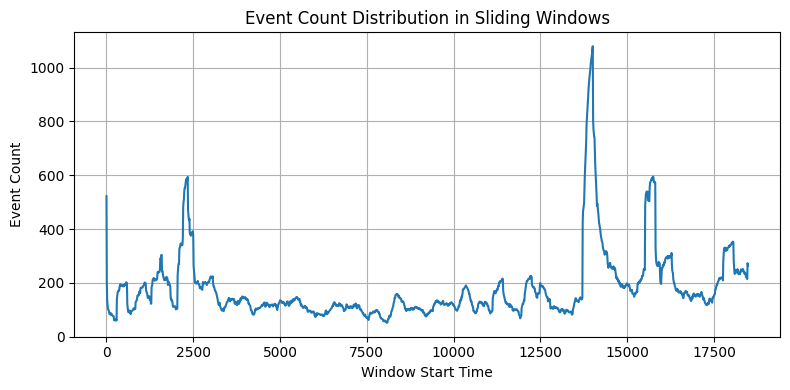

In [11]:
window_size = 300
stride = 10
arrival_times = catalog_ds.full_sequence.arrival_times
max_time = arrival_times.max().item()
window_starts = torch.arange(0, max_time - window_size + stride, stride)
counts = torch.zeros(len(window_starts), dtype=torch.int32)

for i, start in enumerate(window_starts):
    end = start + window_size
    mask = (arrival_times >= start) & (arrival_times < end)
    counts[i] = mask.sum()

plt.figure(figsize=(8, 4))
plt.plot(window_starts, counts)
plt.xlabel('Window Start Time')
plt.ylabel('Event Count')
plt.title('Event Count Distribution in Sliding Windows')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4.1) Forecast Window Configuration

In [12]:
T_FORECAST = 18000
FORECAST_DURATION = 30
NUM_SAMPLES = 1000
SAMPLES_PER_BATCH = 1000
MAX_SAMPLE_LEN = 6000
PREDICT_B = True

past_seq = test_seq.get_subsequence(0, T_FORECAST)
observed_seq = test_seq.get_subsequence(T_FORECAST, T_FORECAST + FORECAST_DURATION)
print(f'past events: {len(past_seq)} | observed events ({T_FORECAST} to {T_FORECAST + FORECAST_DURATION}): {len(observed_seq)}')

past events: 10836 | observed events (18000 to 18030): 8


## 5) Generate Forecast Samples

In [13]:
def generate_forecasts(
    model,
    past_sequence,
    num_samples: int,
    samples_per_batch: int,
    duration: float,
    max_sample_len: int = 1000,
    predict_b: bool = True,
):
    return sample_tpp_forecasts(
        model,
        past_sequence,
        duration=duration,
        num_samples=num_samples,
        samples_per_batch=samples_per_batch,
        sample_max_length=max_sample_len,
        predict_b=predict_b,
    )


if torch.cuda.is_available():
    model.to(DEVICE)
    past_seq = past_seq.to(DEVICE)

set_seed(0)
all_forecasts = generate_forecasts(
    model=model,
    past_sequence=past_seq,
    num_samples=NUM_SAMPLES,
    samples_per_batch=SAMPLES_PER_BATCH,
    duration=FORECAST_DURATION,
    max_sample_len=MAX_SAMPLE_LEN,
    predict_b=PREDICT_B,
)

print(f'Generated forecasts: {len(all_forecasts)}')

  0%|          | 0/1000 [00:00<?, ?it/s]

Generated forecasts: 1000


In [14]:
import importlib
importlib.reload(src.utils.viz_sequences)

<module 'src.utils.viz_sequences' from '/root/autodl-tmp/em_eqf/src/utils/viz_sequences.py'>

(<Figure size 1500x300 with 3 Axes>,
 (<Axes: title={'center': 'Observed Sequence and Example Forecast Trajectories'}, xlabel='Days since 1970-01-01', ylabel='Magnitude'>,
  <Axes: title={'center': 'Forecast counts'}, xlabel='Frequency', ylabel='Event count in window'>,
  <Axes: ylabel='Cumulative count'>))

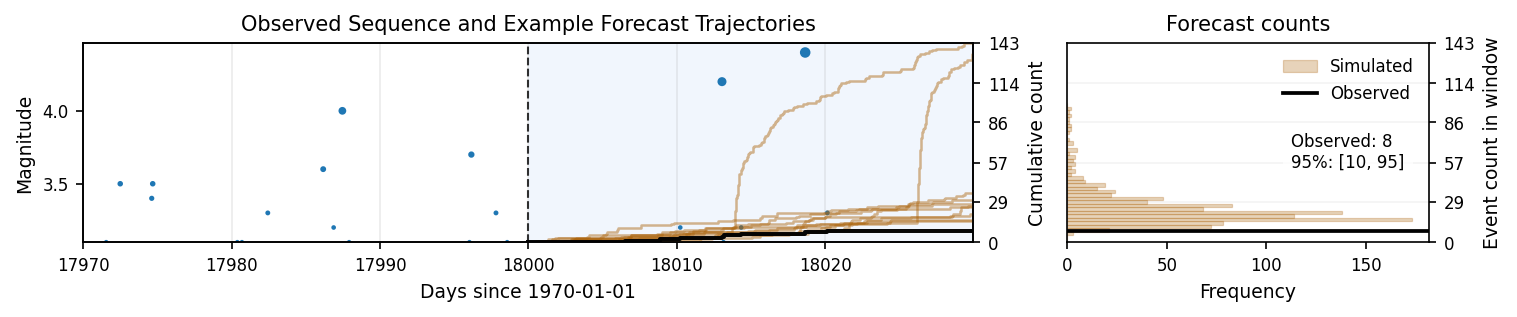

In [15]:
date_str = catalog_ds.metadata['start_ts'].strftime('%Y-%m-%d')
src.utils.viz_sequences.visualize_trajectories(
    test_seq,
    all_forecasts,
    save_path=CHECKPOINT_DIR / f'all_forecasts_{T_FORECAST}.pdf',
    figsize=(10, 2),
    xlabel='Days since ' + date_str,
    offset=20,
    align_count_axes=True,
)

## 6) N-Test (Event Count)

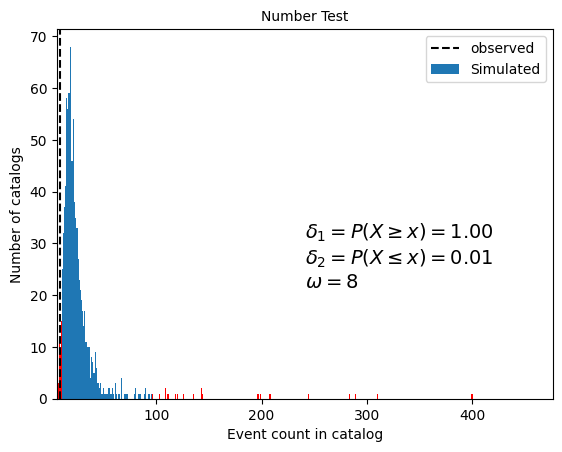

In [16]:
number_test_result = catalog_tests.run_number_test_result(
    event_counts=[len(fc) for fc in all_forecasts],
    obs_count=len(observed_seq),
    min_mw=catalog_ds.metadata['mag_completeness'],
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)

number_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False})
plt.savefig(CHECKPOINT_DIR / f'n_test_{T_FORECAST}.pdf')

## 7) M-Test (Magnitude Distribution)

In [17]:
config_dict = {
    'min_mw': catalog_ds.metadata['mag_completeness'],
    'max_mw': 10,
    'dmw': 0.01,
}


def compute_b_mle(data, mmin, dmw=0.01):
    def _compute_from_mags(mags_t):
        sel = mags_t[mags_t >= mmin]
        n = int(sel.numel())
        if n == 0:
            raise ValueError('No magnitudes above or equal to mmin for b-value calculation.')
        mean_mag = float(sel.mean().item())
        b = 0.4342944819 / (mean_mag - (mmin - dmw / 2))
        b_se = b / (n ** 0.5)
        return b, b_se, n, mean_mag

    def _to_mags(x):
        if hasattr(x, 'mag'):
            x = x.mag
        if isinstance(x, torch.Tensor):
            return x.detach().to(device='cpu', dtype=torch.float32)
        if isinstance(x, np.ndarray):
            return torch.as_tensor(x, dtype=torch.float32, device='cpu')
        if isinstance(x, (list, tuple)) and len(x) > 0 and isinstance(x[0], (int, float)):
            return torch.as_tensor(x, dtype=torch.float32, device='cpu')
        raise TypeError(f'Unsupported input type: {type(x)}')

    if isinstance(data, (list, tuple)):
        per_catalog = []
        all_sel = []

        for cat in data:
            try:
                mags_t = _to_mags(cat)
                sel = mags_t[mags_t >= mmin]
                if sel.numel() == 0:
                    continue
                b_i, b_se_i, n_i, mean_i = _compute_from_mags(mags_t)
                per_catalog.append((float(b_i), float(b_se_i), int(n_i), float(mean_i)))
                all_sel.append(sel)
            except (TypeError, ValueError):
                continue

        if len(per_catalog) == 0:
            raise ValueError('No magnitudes at or above mmin in any catalog.')

        concat = torch.cat(all_sel)
        b_all, b_se_all, n_total, mean_all = _compute_from_mags(concat)
        return {
            'combined': (float(b_all), float(b_se_all), int(n_total), float(mean_all)),
            'per_catalog': per_catalog,
        }

    return _compute_from_mags(_to_mags(data))


b_mle, b_se, n, mean_mag = compute_b_mle(
    observed_seq,
    mmin=args.mag_completeness,
    dmw=config_dict.get('dmw', 0.01),
)
print(f'b (MLE): {b_mle:.3f} ± {b_se:.3f} (N={n}, mmin={args.mag_completeness}, mean={mean_mag:.3f})')

b (MLE): 0.954 ± 0.337 (N=8, mmin=3.0, mean=3.450)


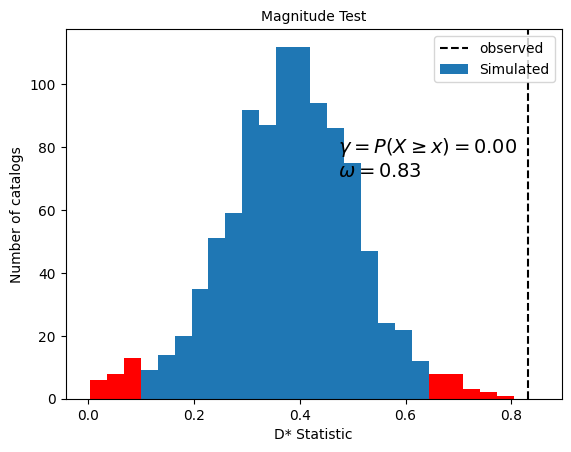

In [18]:
get_counts = functools.partial(catalog_tests.compute_magnitude_distribution, **config_dict)
result_dict = catalog_tests.magnitude_test_from_counts(
    observed_catalog=observed_seq,
    forecast_catalogs=all_forecasts,
    get_counts=lambda cat: get_counts(np.asarray(cat.mag.cpu()))[1],
    verbose=False,
    debug=False,
)

magnitude_test_result = catalog_tests.run_magnitude_test_result(
    result_dict=result_dict,
    obs_catalog_repr='obs',
    obs_name='observed',
    sim_name='Simulated',
    plot=False,
)
magnitude_test_result.plot(plot_args={'figsize': (6.4, 4.8), 'tight_layout': False, 'legend_loc': 'upper right'})
plt.savefig(CHECKPOINT_DIR / f'm_test_{T_FORECAST}.pdf')

In [19]:
CHECKPOINT_DIR

PosixPath('/root/autodl-tmp/em_eqf/checkpoints/etas_20260507-164840')

## 8) Combined Figure: Forecast + M-Test + N-Test

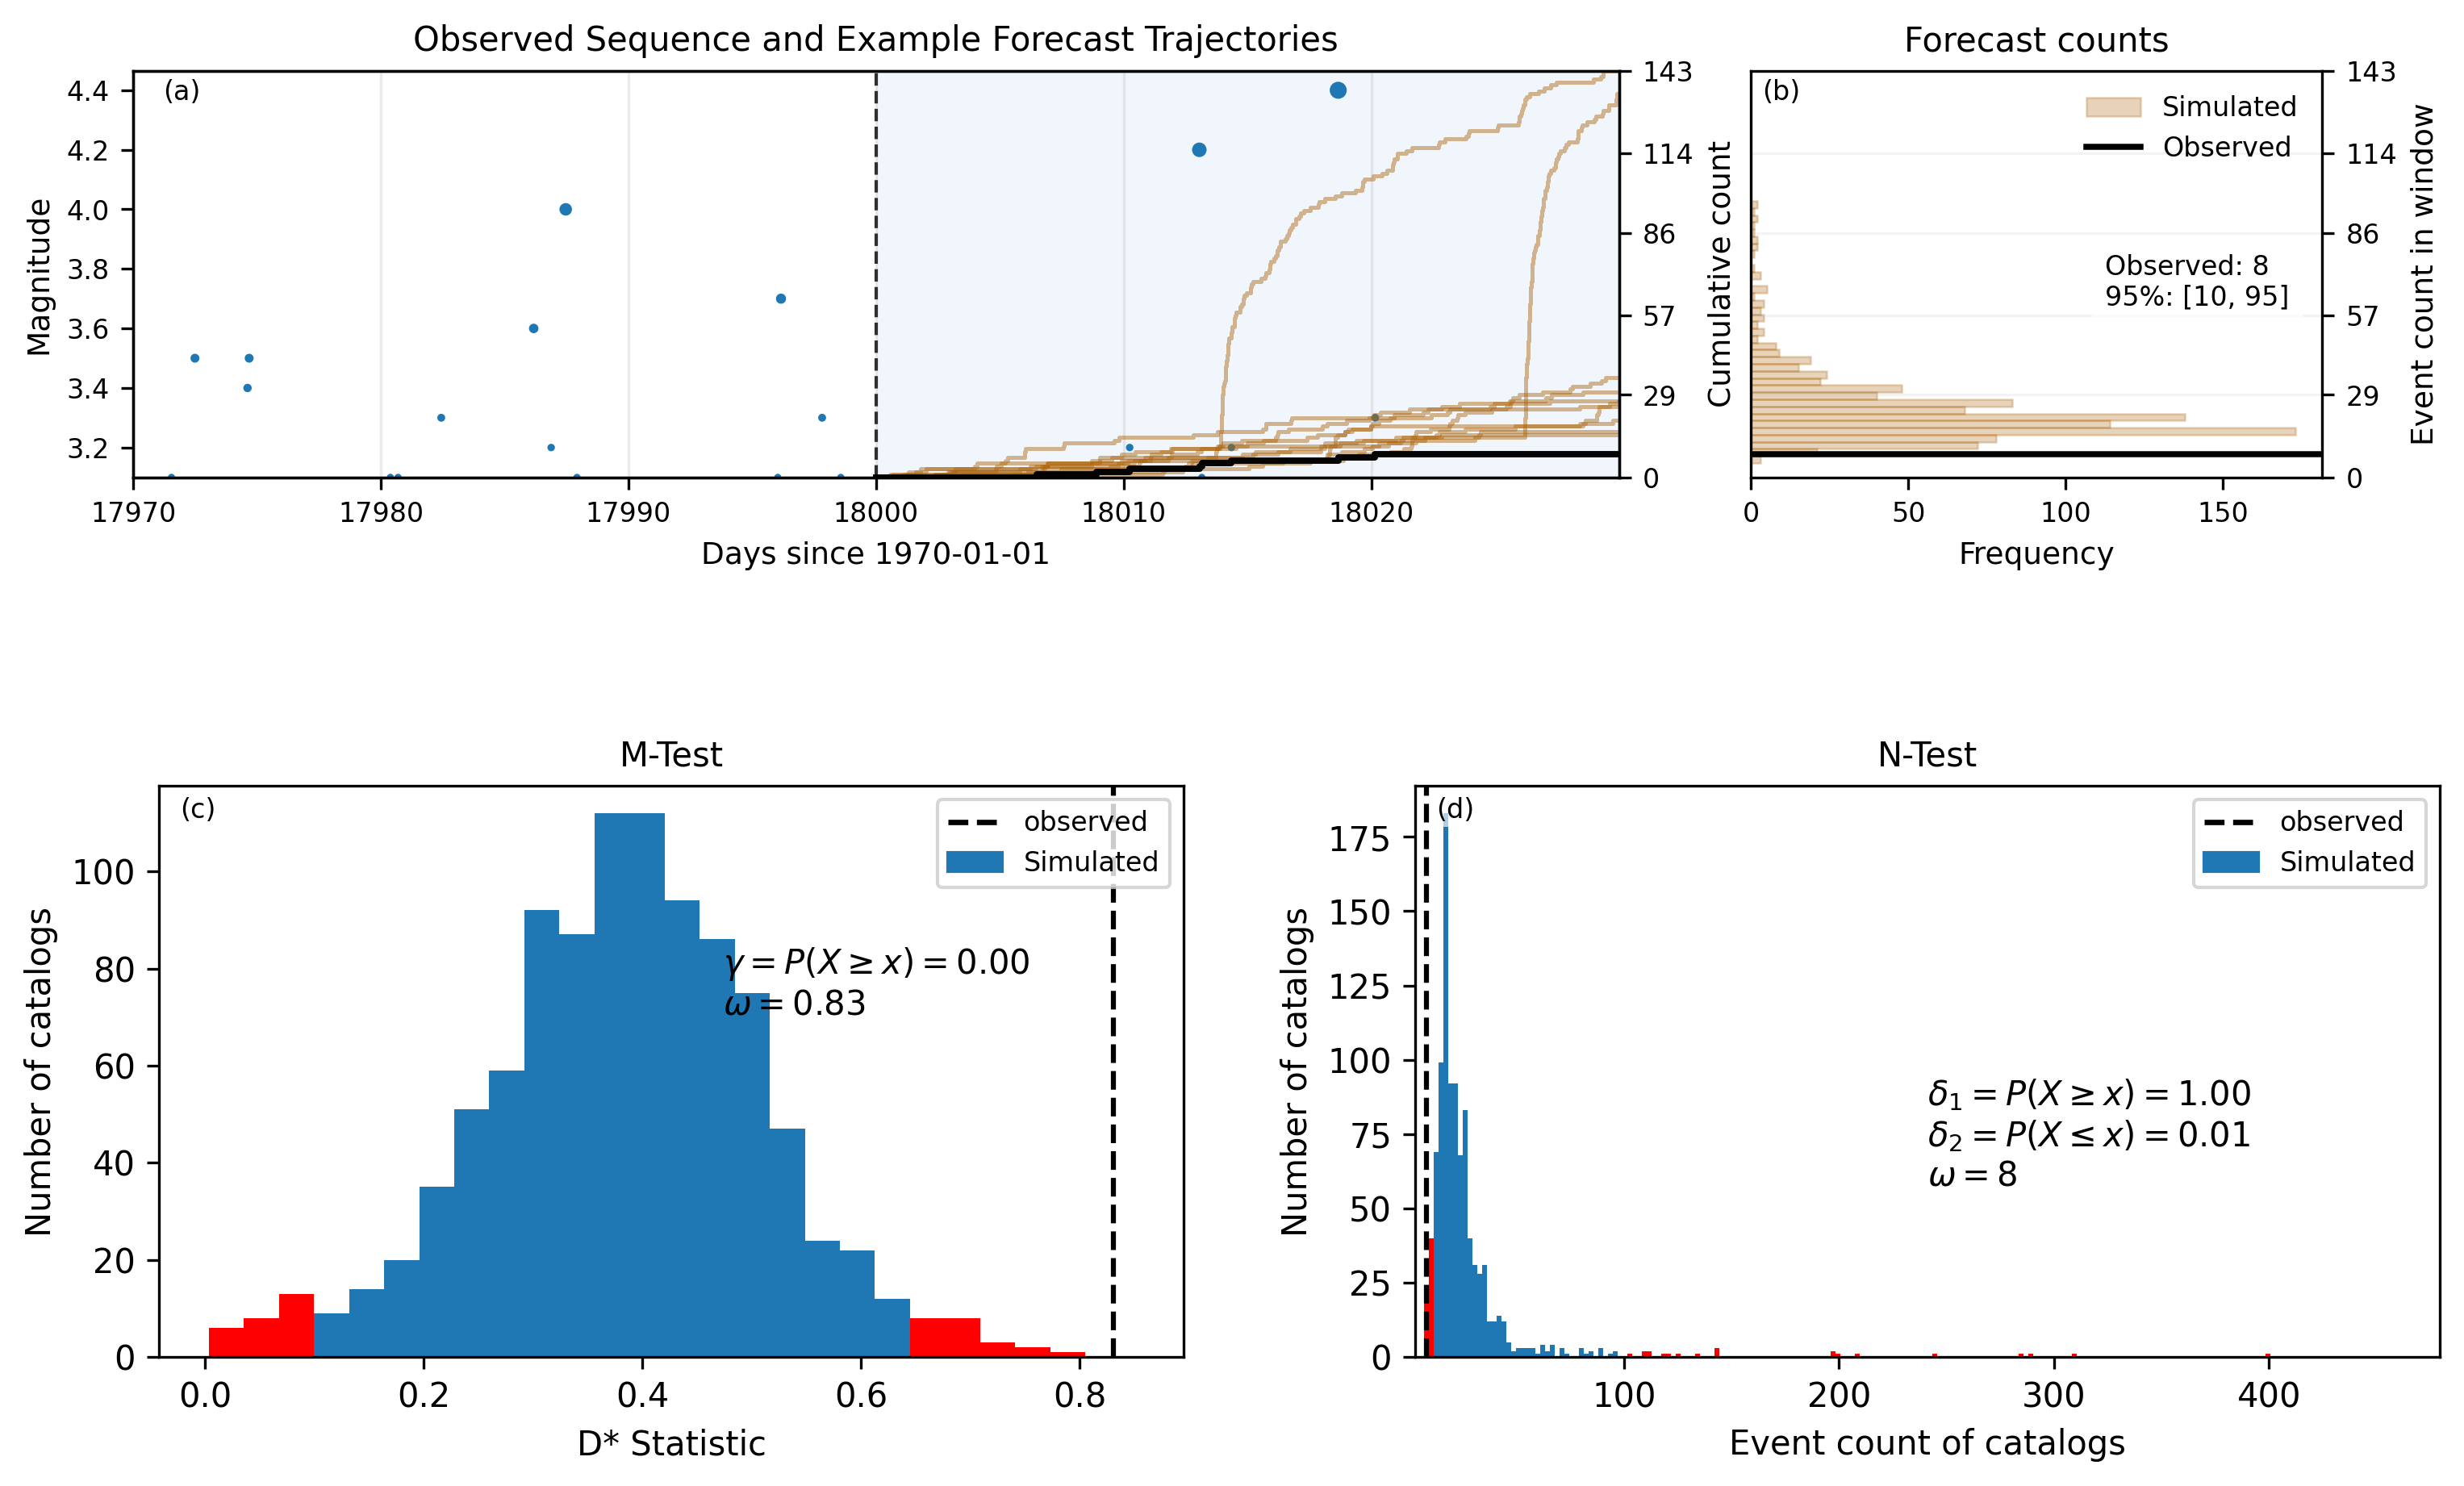

PosixPath('/root/autodl-tmp/em_eqf/checkpoints/etas_20260507-164840/forecast_m_n_combined_18000.pdf')

In [20]:
import importlib
importlib.reload(src.utils.viz_sequences)
combined_pdf_path = CHECKPOINT_DIR / f'forecast_m_n_combined_{T_FORECAST}.pdf'
fig, _ = src.utils.viz_sequences.visualize_forecast_with_tests(
    seq=test_seq,
    forecast=all_forecasts,
    m_test_result=magnitude_test_result,
    n_test_result=number_test_result,
    figsize=(10.0, 6.4),
    trajectory_ref_figsize=(10.0, 2.0),
    row_hspace=0,
    bottom_scale=0.82,
    dpi=300,
    save_path=combined_pdf_path,
    forecast_kwargs={
        'xlabel': 'Days since ' + date_str,
        'offset': 20,
    },
    m_plot_args={
        'title': 'M-Test',
        'percentile': 95,
        'bins': 'auto',
    },
    n_plot_args={
        'title': 'N-Test', 
        'percentile': 95,
    },
)
plt.show()

combined_pdf_path


## 9) Sliding-Window Forecast Evaluation


In [ ]:
# Sliding-window settings
RUN_SLIDING_WINDOW_FORECAST = True  # set to True to run sliding-window forecast (time-consuming)
SLIDING_DURATION = 30
SLIDING_STEP = 120
SLIDING_START = None  # default: test interval start
SLIDING_END = None  # default: test interval end
SLIDING_MAX_SAMPLE_LEN = MAX_SAMPLE_LEN  # increase if "Exceeded max_sample_len" appears
SLIDING_QUANTILES = (2.5, 97.5)
SLIDING_VIEW_MODE = 'zoomed'  # 'zoomed' | 'full' | 'auto'

# Cache settings
SLIDING_LOAD_CACHE = True
SLIDING_FORCE_RECOMPUTE = False
SLIDING_CACHE_FILENAME = 'sliding_window_cache_forecasting.npz'

Sliding-window range: [17532.0, 18771.0]


Sliding window forecast:   0%|          | 0/10 [00:00<?, ?it/s, t_forecast=17562.000]

  0%|          | 0/1000 [00:00<?, ?it/s]

Sliding window forecast:  10%|█         | 1/10 [00:06<00:57,  6.41s/it, t_forecast=17682.000]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

Sliding window forecast:  80%|████████  | 8/10 [00:50<00:13,  6.52s/it, t_forecast=18522.000]

  0%|          | 0/1000 [00:00<?, ?it/s]

Sliding window forecast:  90%|█████████ | 9/10 [00:58<00:06,  6.92s/it, t_forecast=18642.000]

  0%|          | 0/1000 [00:00<?, ?it/s]

Sliding window forecast: 100%|██████████| 10/10 [01:04<00:00,  6.44s/it, t_forecast=18642.000]


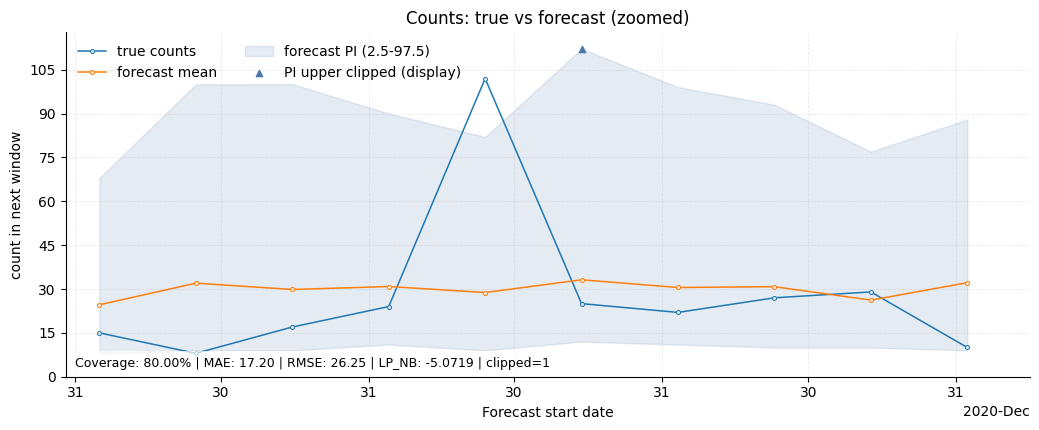

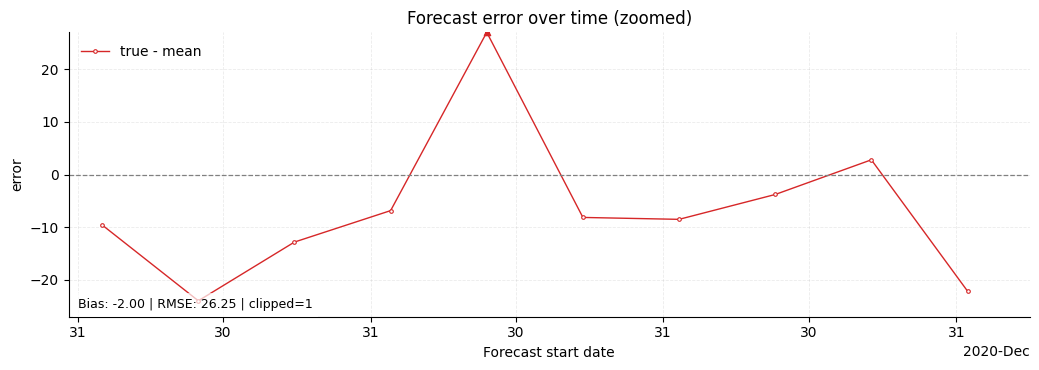

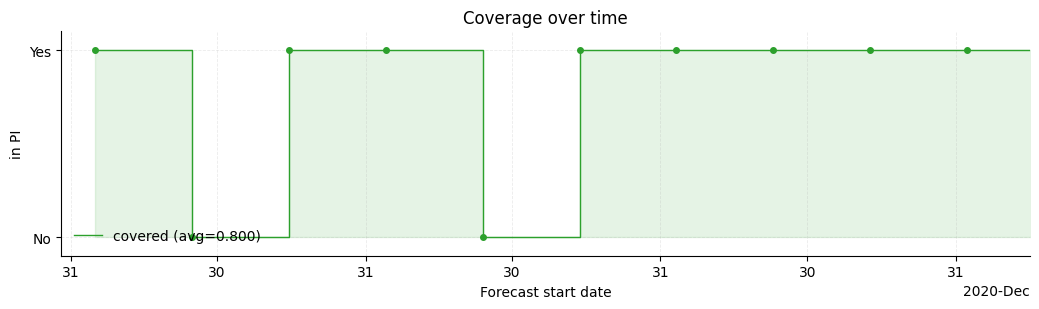

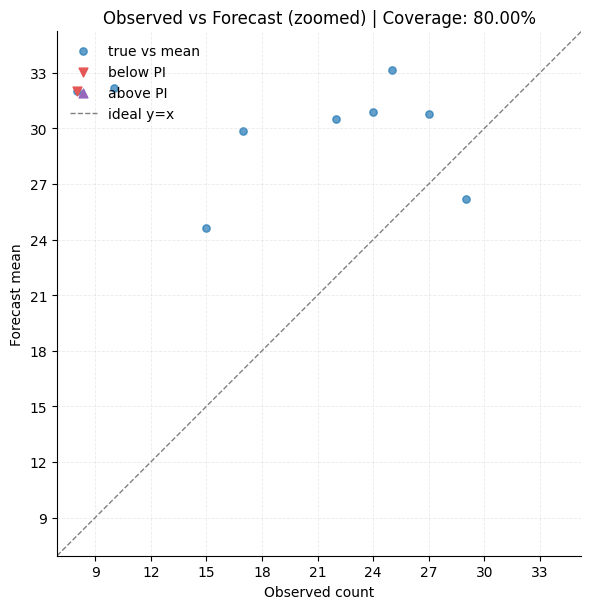

Sliding cache path: /root/autodl-tmp/em_eqf/checkpoints/etas_20260507-164840/sliding_window_cache_forecasting.npz
Loaded from cache: False
acceptance rate: 80.00%
MAE: 17.1960 | RMSE: 26.2528 | LP_NB: -5.0719


In [22]:
from src.utils.forecast_eval import evaluate_sliding_window_forecast_plots

PLOT_COLORS = {
    'true': '#1f77b4',
    'mean': '#ff7f0e',
    'pi': '#4c78a8',
    'err': '#d62728',
    'covered': '#2ca02c',
    'below': '#e45756',
    'above': '#9467bd',
}

if SLIDING_START is None:
    SLIDING_START = float(getattr(test_seq, 't_nll_start', test_seq.t_start))
if SLIDING_END is None:
    SLIDING_END = float(test_seq.t_end)
if SLIDING_START >= SLIDING_END:
    raise ValueError(f'SLIDING_START must be smaller than SLIDING_END, got {SLIDING_START} >= {SLIDING_END}')
print(f'Sliding-window range: [{SLIDING_START}, {SLIDING_END}]')

if RUN_SLIDING_WINDOW_FORECAST:
    sliding_result = evaluate_sliding_window_forecast_plots(
        model=model,
        seq=test_seq,
        device=DEVICE,
        catalog_ds=catalog_ds,
        checkpoint_dir=CHECKPOINT_DIR,
        sliding_duration=SLIDING_DURATION,
        sliding_step=SLIDING_STEP,
        sliding_start=SLIDING_START,
        sliding_end=SLIDING_END,
        sliding_quantiles=SLIDING_QUANTILES,
        samples_per_batch=SAMPLES_PER_BATCH,
        sliding_max_sample_len=SLIDING_MAX_SAMPLE_LEN,
        sliding_view_mode=SLIDING_VIEW_MODE,
        load_sliding_cache=SLIDING_LOAD_CACHE,
        force_recompute_sliding=SLIDING_FORCE_RECOMPUTE,
        sliding_cache_filename=SLIDING_CACHE_FILENAME,
        plot_colors=PLOT_COLORS,
    )

    print(f"Sliding cache path: {sliding_result.get('sliding_cache_path', 'N/A')}")
    print(f"Loaded from cache: {bool(sliding_result.get('sliding_loaded_from_cache', False))}")

    if sliding_result.get('status') == 'empty':
        print(sliding_result['message'])
    else:
        t_forecast_list = sliding_result['t_forecast_list']
        counts_list = sliding_result['counts_list']
        q_list = sliding_result['q_list']
        mean_list = sliding_result['mean_list']
        print(f"acceptance rate: {sliding_result['coverage']:.2%}")
        lp_nb = sliding_result.get('lp_nb')
        if lp_nb is None or not np.isfinite(lp_nb):
            print(f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | LP_NB: N/A")
        else:
            print(f"MAE: {sliding_result['mae']:.4f} | RMSE: {sliding_result['rmse']:.4f} | LP_NB: {lp_nb:.4f}")
else:
    print('Set RUN_SLIDING_WINDOW_FORECAST = True to run sliding-window evaluation.')
